<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Points---sanity" data-toc-modified-id="Points---sanity-1">Points - sanity</a></span></li><li><span><a href="#Lines-&amp;-Projected-Coordinate-System" data-toc-modified-id="Lines-&amp;-Projected-Coordinate-System-2">Lines &amp; Projected Coordinate System</a></span></li><li><span><a href="#Polygons---Geographic-coordinate-system" data-toc-modified-id="Polygons---Geographic-coordinate-system-3">Polygons - Geographic coordinate system</a></span></li><li><span><a href="#Very-large-data" data-toc-modified-id="Very-large-data-4">Very large data</a></span></li></ul></div>

In [7]:
## uncomment this if you are testing a non-installed version of the Python API and update the path
# ##
# import sys
# sys.path.insert(0, r"E:\\code\\geosaurus\\geosaurus\\src")
# import os

In [1]:
import arcgis
print(arcgis.__file__)
import pandas as pd
from arcgis.features import GeoAccessor
import geopandas as gpd
import matplotlib.pyplot as plt
import os

%matplotlib inline

e:\code\geosaurus\geosaurus\src\arcgis\__init__.py


In [2]:
data_path = r'\\qalab_server\pydata\v108\geosaurus\data_prep\spatial_ref_tests'
large_data_path = r'\\qalab_server\pydata\v108\geosaurus\Esri_Geoanalytics_datasets'

In [3]:
from arcgis.gis import GIS
gis = GIS()

## Points - sanity

In [4]:
%%time
file_path = os.path.join(data_path, 'points_gcs_nad83.shp')
geo_df = gpd.read_file(file_path)

Wall time: 131 ms


In [5]:
geo_df.shape

(317, 30)

In [6]:
geo_df.head(2)

,objectid,post_id,name,descriptio,cat1,cat2,cat3,addrln1,addrln2,city,...,source,ext_id,use_type,dis_status,latitude,longitude,date_updat,point_x,point_y,geometry
0,40221950,638.0,Hollywood Community Hospital,The agency provides hospital services for peop...,Health and Mental Health,Hospitals and Medical Centers,None,6245 De Longpre Ave.,None,Hollywood,...,211,None,publish,None,34.096313,-118.325079,2013-06-01,6.463252e+06,1.857590e+06,POINT (-118.32508 34.09631)
1,40222889,1268.0,Los Angeles Community Hospital,The facility provides hospital services for pe...,Health and Mental Health,Hospitals and Medical Centers,None,4081 E. Olympic Blvd.,None,Los Angeles,...,211,None,publish,None,34.019102,-118.186366,2013-06-01,6.505195e+06,1.829384e+06,POINT (-118.18637 34.01910)


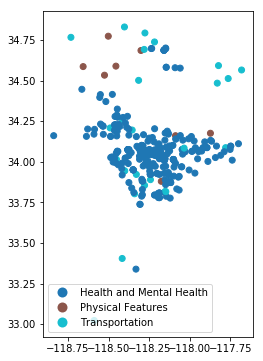

In [7]:
fig, ax = plt.subplots(figsize=(6,6))
geo_df.plot(column ='cat1', legend=True, ax=ax);

In [8]:
%%time
sedf = pd.DataFrame.spatial.from_geodataframe(geo_df)
sedf.shape

Wall time: 22.5 ms


In [9]:
sedf.head(2)

,objectid,post_id,name,descriptio,cat1,cat2,cat3,addrln1,addrln2,city,...,source,ext_id,use_type,dis_status,latitude,longitude,date_updat,point_x,point_y,SHAPE
0,40221950,638.0,Hollywood Community Hospital,The agency provides hospital services for peop...,Health and Mental Health,Hospitals and Medical Centers,None,6245 De Longpre Ave.,None,Hollywood,...,211,None,publish,None,34.096313,-118.325079,2013-06-01,6.463252e+06,1.857590e+06,"{'x': -118.32507905610994, 'y': 34.09631296733..."
1,40222889,1268.0,Los Angeles Community Hospital,The facility provides hospital services for pe...,Health and Mental Health,Hospitals and Medical Centers,None,4081 E. Olympic Blvd.,None,Los Angeles,...,211,None,publish,None,34.019102,-118.186366,2013-06-01,6.505195e+06,1.829384e+06,"{'x': -118.1863660563472, 'y': 34.019101966362..."


MapView(layout=Layout(height='400px', width='100%'))


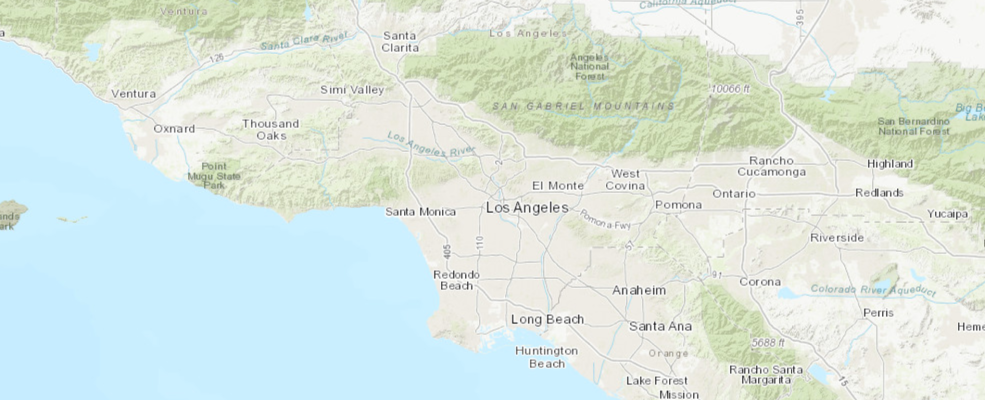

In [10]:
map1 = gis.map('Los Angeles, CA')
map1

In [11]:
sedf.spatial.plot(map1)
map1.take_screenshot(output_in_cell=False)

In [12]:
print(sedf.spatial.sr, geo_df.crs)

{'wkid': 4269} {'init': 'epsg:4269'}


## Lines & Projected Coordinate System

In [13]:
file_path = os.path.join(data_path, 'lines_pcs_wgs84_utm_z15n.shp')
geo_df = gpd.read_file(file_path)

In [14]:
print(geo_df.shape)
geo_df.head(2)

(197, 6)


,TextField,DateField,RepRowID,Enabled,SHAPE_Leng,geometry
0,GN,2009-03-17,1,1,59.403290,"LINESTRING (494930.125 4980335.462, 494948.221..."
1,GN,2009-03-17,2,1,77.864384,"LINESTRING (494948.221 4980334.866, 494971.954..."


In [15]:
geo_df.crs # prints EPSG for UTM, Zone 15 N

{'init': 'epsg:32615'}

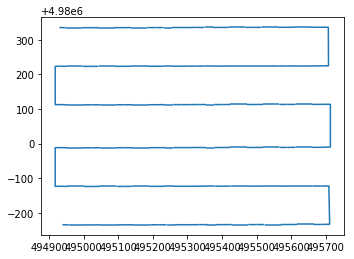

In [16]:
geo_df.plot()

In [17]:
%%time
sedf= pd.DataFrame.spatial.from_geodataframe(geo_df)
print(sedf.shape)
print(sedf.head(2))

(197, 6)
  TextField   DateField  RepRowID  Enabled  SHAPE_Leng  \
0        GN  2009-03-17         1        1   59.403290   
1        GN  2009-03-17         2        1   77.864384   

                                               SHAPE  
0  {'paths': [[(494930.12504355464, 4980335.46186...  
1  {'paths': [[(494948.22138007096, 4980334.86554...  
Wall time: 28 ms


In [18]:
sedf.iloc[0]['SHAPE']['spatialReference'] # preserved as earlier

{'wkid': 32615}

MapView(layout=Layout(height='400px', width='100%'), zoom=13.0)


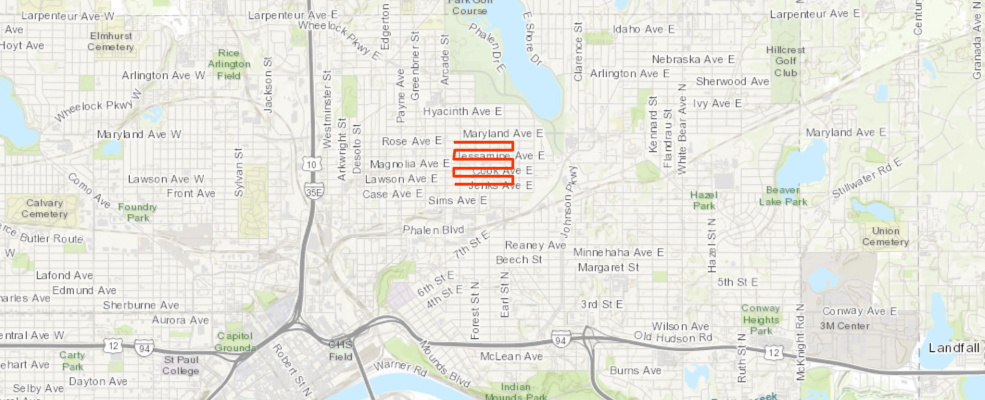

In [19]:
map2b = gis.map()
map2b.center={'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
 'x': -10359153.165404981,
 'y': 5616711.30103032}
map2b.zoom=13
map2b

In [20]:
sedf.spatial.plot(map2b)

True

In [21]:
map2b.take_screenshot(output_in_cell=False) # fails to plot as the crs is wrong

## Polygons - Geographic coordinate system

In [22]:
%%time
file_path = os.path.join(data_path, 'polygons_gcs_wgs84.shp')
geo_df = gpd.read_file(file_path)
print(geo_df.shape)

(192, 6)
Wall time: 37 ms


In [23]:
geo_df.head(2)

,RepRowID,TextField,DateField,SHAPE_Leng,SHAPE_Area,geometry
0,1,GN,2009-03-17,397.743626,9378.271399,"POLYGON ((-93.06392 44.97687, -93.06392 44.976..."
1,2,GN,2009-03-17,397.743626,9378.271399,"POLYGON ((-93.06362 44.97687, -93.06362 44.976..."


In [24]:
%%time
sedf = pd.DataFrame.spatial.from_geodataframe(geo_df)
print(sedf.shape)

(192, 6)
Wall time: 32.5 ms


In [25]:
sedf.head(2)

,RepRowID,TextField,DateField,SHAPE_Leng,SHAPE_Area,SHAPE
0,1,GN,2009-03-17,397.743626,9378.271399,"{'rings': [[(-93.06392094799334, 44.9768713364..."
1,2,GN,2009-03-17,397.743626,9378.271399,"{'rings': [[(-93.06362116208389, 44.9768718658..."


MapView(layout=Layout(height='400px', width='100%'), zoom=16.0)


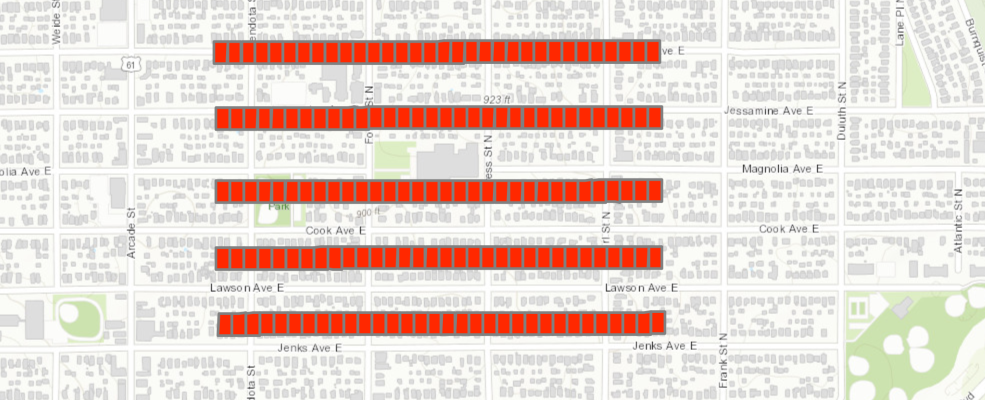

In [26]:
map3 = gis.map()
map3.center={'spatialReference': {'latestWkid': 3857, 'wkid': 102100},
 'x': -10359193.77257626,
 'y': 5617344.295170828}
map3.zoom=16
map3

In [27]:
sedf.spatial.plot(map3)

True

In [28]:
map3.take_screenshot(output_in_cell=False)

## Very large data
Change cell type to `code` if you want to run against very large data.

%%time
file1_path = os.path.join(r'\\qalab_server\pydata\v108\geosaurus\Esri_Geoanalytics_datasets\NYCTaxi_2\2015', 
                          'nyc_2015_01.shp')
geo_df = gpd.read_file(file1_path)
print(geo_df.shape)

from sys import getsizeof

getsizeof(geo_df)/(1000*1000*1000)  # size in GB

geo_df.info()

%%time
sedf = pd.DataFrame.spatial.from_geodataframe(geo_df)
print(sedf.shape)